In [62]:
import gfapy
import networkx as nx
import numpy as np
from itertools import product
from dimod import BQM
from dwave.system import LeapHybridSampler
from dimod.reference.samplers import SimulatedAnnealingSampler
from math import floor
import re

In [63]:
def array_to_path(arr):
    nz = np.nonzero(arr == 1)
    return [(nz[0][i], nodes[nz[1][i]] if nz[1][i] in range(V) else 'end') for i in range(nz[0].shape[0])]
        

In [64]:
def invert_orient(orient: str):
    if orient == '+':
        return '-'
    elif orient == '-':
        return '+'
    else:
        raise Exception('Bad orient')

In [65]:
def oriented_graph_from_file(filename):
    """Reads a .gfa file into the dual graph.

    Args:
        filename (str): filepath to read.

    Returns:
        nx.Graph: corresponding oriented graph.
    """
    gfa = gfapy.Gfa.from_file(filename, vlevel=0)
    graph = nx.DiGraph()
    for edge_line in gfa.edges:
        v1 = edge_line.sid1
        v2 = edge_line.sid2
        forward_node = f'{v1.name}{v1.orient}_{v2.name}{v2.orient}'
        graph.add_node(forward_node, weight=edge_line.EC)
        backward_node = f'{v2.name}{invert_orient(v2.orient)}_{v1.name}{invert_orient(v1.orient)}'
        graph.add_node(backward_node, weight=edge_line.EC)
        for node in graph.nodes:
            node_matches = re.search(
                r'(.+[\+\-])_(.+[\+\-])',
                node
            )
            node_start = node_matches.group(1)
            node_end = node_matches.group(2)
            if node_start == f'{v2.name}{v2.orient}':
                graph.add_edges_from([(forward_node, node)])
            if node_start == f'{v1.name}{invert_orient(v1.orient)}':
                graph.add_edges_from([(backward_node, node)])
            if node_end == f'{v1.name}{v1.orient}':
                graph.add_edges_from([(node, forward_node)])
            if node_end == f'{v2.name}{invert_orient(v2.orient)}':
                graph.add_edges_from([(node, backward_node)])
                
    return graph

In [66]:
def normalise_node_weights(graph, normalisation):
    for node in graph.nodes:
        graph.nodes[node]["weight"] = round(graph.nodes[node]["weight"] / normalisation)
    return graph

In [67]:
g = oriented_graph_from_file('../../data/test.gfa')
# g = oriented_graph_from_file('../../data/ddDapMeze1.MT.k501.utg.final.gfa')
# g = normalise_node_weights(g, 100)

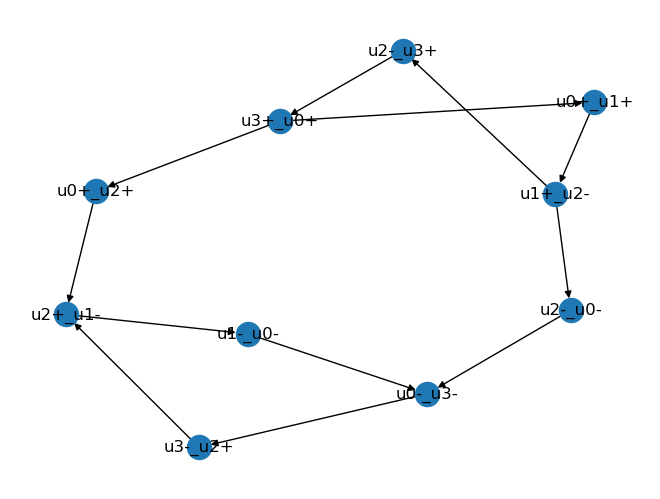

In [68]:
nx.draw_kamada_kawai(g, with_labels=True)

In [69]:
nodes = list(g.nodes)
V = int(len(nodes))
total_weight = int(sum(g.nodes[node]["weight"] for node in nodes) / 2)
alpha = 1.2
T_max = int(total_weight * alpha)
qubo_matrix = np.zeros((T_max, V + 1, T_max, V + 1))

lambda_t = 3 * T_max
lambda_g = 1 * T_max
lambda_end = floor(1 * T_max)
lambda_w = floor(1 * T_max)

In [70]:
# Path
for t in range(T_max):
    for i in range(V):
        qubo_matrix[t, i, t, i] -= lambda_t
        qubo_matrix[t, V, t, i] += 2 * lambda_t
    qubo_matrix[t, V, t, V] -= lambda_t
    
    for i, j in product(range(V), range(V)):
        if not (i == j):
            qubo_matrix[t, i, t, j] += lambda_t
    
# Graph
for t in range(T_max - 1):
    for i, j in product(range(V), range(V)):
        if (nodes[i], nodes[j]) in g.edges:
            qubo_matrix[t, i, t+1, j] -= lambda_g

# Staying in end
for t in range(T_max - 1):
    for i in range(V):
        qubo_matrix[t, i, t + 1, V] -= (lambda_g - 1)
    qubo_matrix[t, V, t + 1, V] -= (lambda_g - 1)
    
# Leaving end
for t in range(T_max - 1):
    for i in range(V):
        qubo_matrix[t, V, t + 1, i] += lambda_end
            
# Weights
for i in range(0, V, 2):
    for t in range(T_max):
        qubo_matrix[t, i, t, i] -= (2 * g.nodes[nodes[i]]["weight"] - 1) * lambda_w
        qubo_matrix[t, i + 1, t, i + 1] -= (2 * g.nodes[nodes[i]]["weight"] - 1) * lambda_w
    
    for t1, t2 in product(range(T_max), range(T_max)):
        qubo_matrix[t1, i, t2, i + 1] += 2 * lambda_w
        if not (t1 == t2):
            qubo_matrix[t1, i, t2, i] += lambda_w
            qubo_matrix[t1, i + 1, t2, i + 1] += lambda_w

qubo_matrix = qubo_matrix.reshape((T_max * (V+1)), (T_max * (V+1)))
qubo_matrix = 0.5 * (qubo_matrix + qubo_matrix.T)

In [71]:
bqm = BQM(qubo_matrix, 'BINARY')
bqm.offset = -1 * (lambda_g * (1 - T_max) + (T_max - total_weight)) + (T_max * lambda_t + lambda_w * sum(g.nodes[nodes[i]]["weight"] ** 2 for i in range(0, V, 2)))
bqm.offset

167.0

In [72]:
print(bqm.num_interactions)
print(np.max(qubo_matrix))
print(np.min(qubo_matrix))

795
24.0
-24.0


In [73]:
sim_annealer = SimulatedAnnealingSampler()

In [74]:
sampleset = sim_annealer.sample(bqm, num_reads=10)

In [75]:
sample = sampleset.first.sample
energy = sampleset.first.energy
print(energy)
sample_list = np.array(list(sample.values()))
sample_array = sample_list.reshape((T_max, V + 1))
print(array_to_path(sample_array))

12.0
[(0, 'u0+_u2+'), (1, 'u0+_u1+'), (2, 'u0-_u3-'), (3, 'u3-_u2+'), (4, 'u2+_u1-'), (5, 'end')]


In [76]:
def t_score(sample_arr):
    return sum(
        lambda_t * (1 - sum(sample_arr[t, i] for i in range(V)) - sample_arr[t, V]) ** 2 for t in range(T_max)
    )

def g_score(sample_arr):
    return -lambda_g * sum(
        sample_arr[t, i] * sample_arr[t+1, j] * (1 if (nodes[i], nodes[j]) in g.edges else 0)
        for t in range(T_max - 1) for i in range(V) for j in range(V)
    )   

def g_end_score(sample_arr):
    return -(lambda_g - 1) * sum(
        sum(sample_arr[t, i] * sample_arr[t+1, V] for i in range(V)) 
        + sample_arr[t, V] * sample_arr[t + 1, V] for t in range(T_max - 1) 
    )
    
def end_score(sample_arr):
    return lambda_end * sum(sample_arr[t, V] * sample_arr[t + 1, i] for t in range(T_max - 1) for i in range(V))

def weight_score(sample_arr):
    return lambda_w * sum(
        (g.nodes[nodes[i]]["weight"] - sum(sample_arr[t, i] + sample_arr[t, i + 1] for t in range(T_max))) ** 2 for i in range(0, V, 2)
    )

In [77]:
print(t_score(sample_array))
print(g_score(sample_array))
print(g_end_score(sample_array))
print(end_score(sample_array))
print(weight_score(sample_array))
print()
print(-lambda_g * (1 - T_max) - (T_max - total_weight))
print(bqm.energy(sample))

0
-12
-5
0
0

29
12.0


In [78]:
test_sample = np.zeros((T_max, V + 1))
test_sample[0, 0] = 1
test_sample[1, 2] = 1
test_sample[2, 4] = 1
test_sample[3, 6] = 1
test_sample[4, 8] = 1
test_sample[5, 10] = 1
test_sample_list = test_sample.reshape(T_max * (V + 1))

In [79]:
print(t_score(test_sample))
print(g_score(test_sample))
print(g_end_score(test_sample))
print(end_score(test_sample))
print(weight_score(test_sample))
print()
print(-lambda_g * (1 - T_max) - (T_max - total_weight))
print(bqm.energy(test_sample_list))

0.0
-24.0
-5.0
0.0
0.0

29
0.0


In [561]:
hybrid_sampler = LeapHybridSampler()
hybrid_sampleset = hybrid_sampler.sample(bqm, label="Edge Tangle Testing", time_limit=30)

In [562]:
hybrid_sample = hybrid_sampleset.first.sample
hybrid_energy = hybrid_sampleset.first.energy
hybrid_sample_list = np.array(list(hybrid_sample.values()))
hybrid_sample_array = hybrid_sample_list.reshape((T_max, V + 1))

In [563]:
# print(array_to_path(sample_array))
# print(array_to_path(test_sample))
print(array_to_path(hybrid_sample_array))
# u5-,u3-,u0-,u2+,u9+,u6-,u5+,u4-,u0-,u2+,u9+,u11+,u15+,u16+,u14-,u13-,u12+,u11-,u9-,u2-,u1+,u13-,u10-,u9-,u8+,u16-,u7-

[(0, 'u15-_u11-'), (1, 'u11-_u9-'), (2, 'u9-_u2-'), (3, 'u2-_u1+'), (4, 'u1+_u13-'), (5, 'u13-_u10-'), (6, 'u10-_u9-'), (7, 'u9-_u2-'), (8, 'u2-_u0+'), (9, 'u0+_u3+'), (10, 'u3+_u5+'), (11, 'u5+_u4-'), (12, 'u4-_u0-'), (13, 'u0-_u2+'), (14, 'u2+_u9+'), (15, 'u9+_u6-'), (16, 'u6-_u5+'), (17, 'u5+_u7+'), (18, 'u7+_u16+'), (19, 'u16+_u14-'), (20, 'u14-_u13-'), (21, 'u13-_u12+'), (22, 'u12+_u11-'), (23, 'u11-_u9-'), (24, 'u9-_u8+'), (25, 'u8+_u16-'), (26, 'u16-_u15-'), (27, 'end'), (28, 'end'), (29, 'end'), (30, 'end'), (31, 'end')]


In [564]:
print(t_score(hybrid_sample_array))
print(g_score(hybrid_sample_array))
print(g_end_score(hybrid_sample_array))
print(end_score(hybrid_sample_array))
print(weight_score(hybrid_sample_array))
print()
print(-lambda_g * (1 - T_max) - (T_max - total_weight))
print(bqm.energy(hybrid_sample_list))

0
-832
-155
0
0

987
0.0


In [555]:
off_weights = [(g.nodes[nodes[i]]["weight"] - sum(hybrid_sample_array[t, i] + hybrid_sample_array[t, i + 1] for t in range(T_max))) for i in range(0, V, 2)]

In [556]:
off_weights
# 0+3+, 2+9+, 2-0+, 3+5+, 9+10+

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [557]:
best_path_nodes = ['u5-','u3-','u0-','u2+','u9+','u6-','u5+','u4-','u0-','u2+','u9+','u11+','u15+','u16+','u14-','u13-','u12+','u11-','u9-','u2-','u1+','u13-','u10-','u9-','u8+','u16-','u7-', 'u5-']
best_path = [f'{best_path_nodes[i]}_{best_path_nodes[i+1]}' for i in range(len(best_path_nodes) - 1)]
best_path_sample = np.zeros_like(hybrid_sample_array)
for i in range(len(best_path)):
    best_path_sample[i, nodes.index(best_path[i])] = 1
best_path_sample[i+1:, -1] = 1
print(array_to_path(best_path_sample))


[(0, 'u5-_u3-'), (1, 'u3-_u0-'), (2, 'u0-_u2+'), (3, 'u2+_u9+'), (4, 'u9+_u6-'), (5, 'u6-_u5+'), (6, 'u5+_u4-'), (7, 'u4-_u0-'), (8, 'u0-_u2+'), (9, 'u2+_u9+'), (10, 'u9+_u11+'), (11, 'u11+_u15+'), (12, 'u15+_u16+'), (13, 'u16+_u14-'), (14, 'u14-_u13-'), (15, 'u13-_u12+'), (16, 'u12+_u11-'), (17, 'u11-_u9-'), (18, 'u9-_u2-'), (19, 'u2-_u1+'), (20, 'u1+_u13-'), (21, 'u13-_u10-'), (22, 'u10-_u9-'), (23, 'u9-_u8+'), (24, 'u8+_u16-'), (25, 'u16-_u7-'), (26, 'u7-_u5-'), (27, 'end'), (28, 'end'), (29, 'end'), (30, 'end'), (31, 'end')]


In [558]:
print(t_score(best_path_sample))
print(g_score(best_path_sample))
print(g_end_score(best_path_sample))
print(end_score(best_path_sample))
print(weight_score(best_path_sample))

best_path_sample_list = best_path_sample.reshape(T_max * (V + 1))
print(bqm.energy(best_path_sample_list))
best_path_sample_list @ qubo_matrix @ best_path_sample_list + (T_max * lambda_t + lambda_w * sum(g.nodes[nodes[i]]["weight"] ** 2 for i in range(0, V, 2)))

0
-832
-155
0
0
0.0


-987.0